# Homework 03 — Python Fundamentals

This notebook demonstrates NumPy operations, pandas data loading and inspection, summary statistics, groupby aggregation, reusable utility functions, and saving processed outputs.

In [1]:
import numpy as np
import pandas as pd
import time

## 1. NumPy Operations

In [3]:
# Create a NumPy array
arr = np.array([1, 2, 3, 4, 5])

print("Original array:", arr)
print("Add 10:", arr + 28)
print("Multiply by 2:", arr * 2)
print("Square:", arr ** 2)

Original array: [1 2 3 4 5]
Add 10: [29 30 31 32 33]
Multiply by 2: [ 2  4  6  8 10]
Square: [ 1  4  9 16 25]


In [4]:
large_arr = np.arange(1_000_000)

## 2. Loop vs Vectorized Execution

In [5]:
# Loop execution
start = time.perf_counter()

loop_result = []
for x in large_arr:
    loop_result.append(x * 2)

loop_time = time.perf_counter() - start

print("Loop time:", loop_time)

Loop time: 0.28575736199999824


In [6]:
# Vectorized NumPy execution
start = time.perf_counter()

vectorized_result = large_arr * 2

vectorized_time = time.perf_counter() - start

print("Vectorized time:", vectorized_time)

Vectorized time: 0.006334017000000358


In [7]:
print("Speedup:", loop_time / vectorized_time)

Speedup: 45.1147134590864


NumPy vectorized operations are substantially faster because the operation is executed on the entire array using optimized low-level routines rather than processing each element individually in a Python loop.

## 3. Load and Inspect Dataset

In [16]:
df = pd.read_csv("data/raw/starter_data.csv")

In [17]:
df.head()

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


In [19]:
df.columns

Index(['category', 'value', 'date'], dtype='object')

## 4. Summary Statistics

In [21]:
summary_stats = df.describe()

summary_stats

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [22]:
df.columns.tolist()

['category', 'value', 'date']

## 5. GroupBy Aggregation

In [23]:
grouped_summary = (
    df.groupby("category")["value"]
    .agg(["count", "mean", "median", "min", "max"])
)

grouped_summary

,count,mean,median,min,max
category,,,,,
A,4,11.500000,11.5,10,13
B,3,15.666667,15.0,14,18
C,3,27.666667,28.0,25,30


## 6. Reusable Functions

In [25]:

import sys

sys.path.append("./src")

from utils import get_summary_stats, get_grouped_summary

In [26]:
summary_from_function = get_summary_stats(df)

summary_from_function

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [27]:
grouped_from_function = get_grouped_summary(
    df,
    group_col="category",
    numeric_col="value"
)

grouped_from_function

,category,count,mean,median,min,max
0,A,4,11.500000,11.5,10,13
1,B,3,15.666667,15.0,14,18
2,C,3,27.666667,28.0,25,30


## 7. Save Processed Outputs

In [34]:
summary_stats.to_csv(
    "data/processed/summary.csv",
    index_label="statistic"
)

In [35]:
saved_summary = pd.read_csv("data/processed/summary.csv")

saved_summary.head()

,statistic,value
0,count,10.000000
1,mean,17.600000
2,std,7.381659
3,min,10.000000
4,25%,12.250000


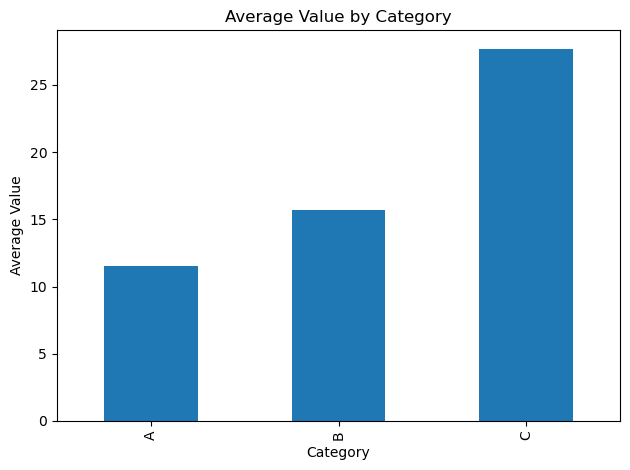

In [36]:
import matplotlib.pyplot as plt
group_mean = df.groupby("category")["value"].mean()

group_mean.plot(kind="bar")

plt.title("Average Value by Category")
plt.xlabel("Category")
plt.ylabel("Average Value")
plt.tight_layout()

plt.savefig("data/processed/group_summary_plot.png")
plt.show()